In [1]:
#1: Load Libraries & Dataset


In [2]:
# 1.1 Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1.2 Load the dataset (note: sep='\t' for tab-separated file)
df = pd.read_csv('marketing_campaign.csv', sep='\t')

# 1.3 Display first 5 rows
print("FIRST 5 ROWS:")
print(df.head())

# 1.4 Dataset information
print("\n" + "="*60)
print("DATASET INFO:")
print("="*60)
print(df.info())

# 1.5 Check for missing values
print("\n" + "="*60)
print("MISSING VALUES:")
print("="*60)
print(df.isnull().sum())

# 1.6 Handle missing values (drop rows with missing Income - there are 24)
df_clean = df.dropna(subset=['Income'])
print(f"\nRows after dropping missing Income: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

FIRST 5 ROWS:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0

In [3]:
#2: Data Visualization

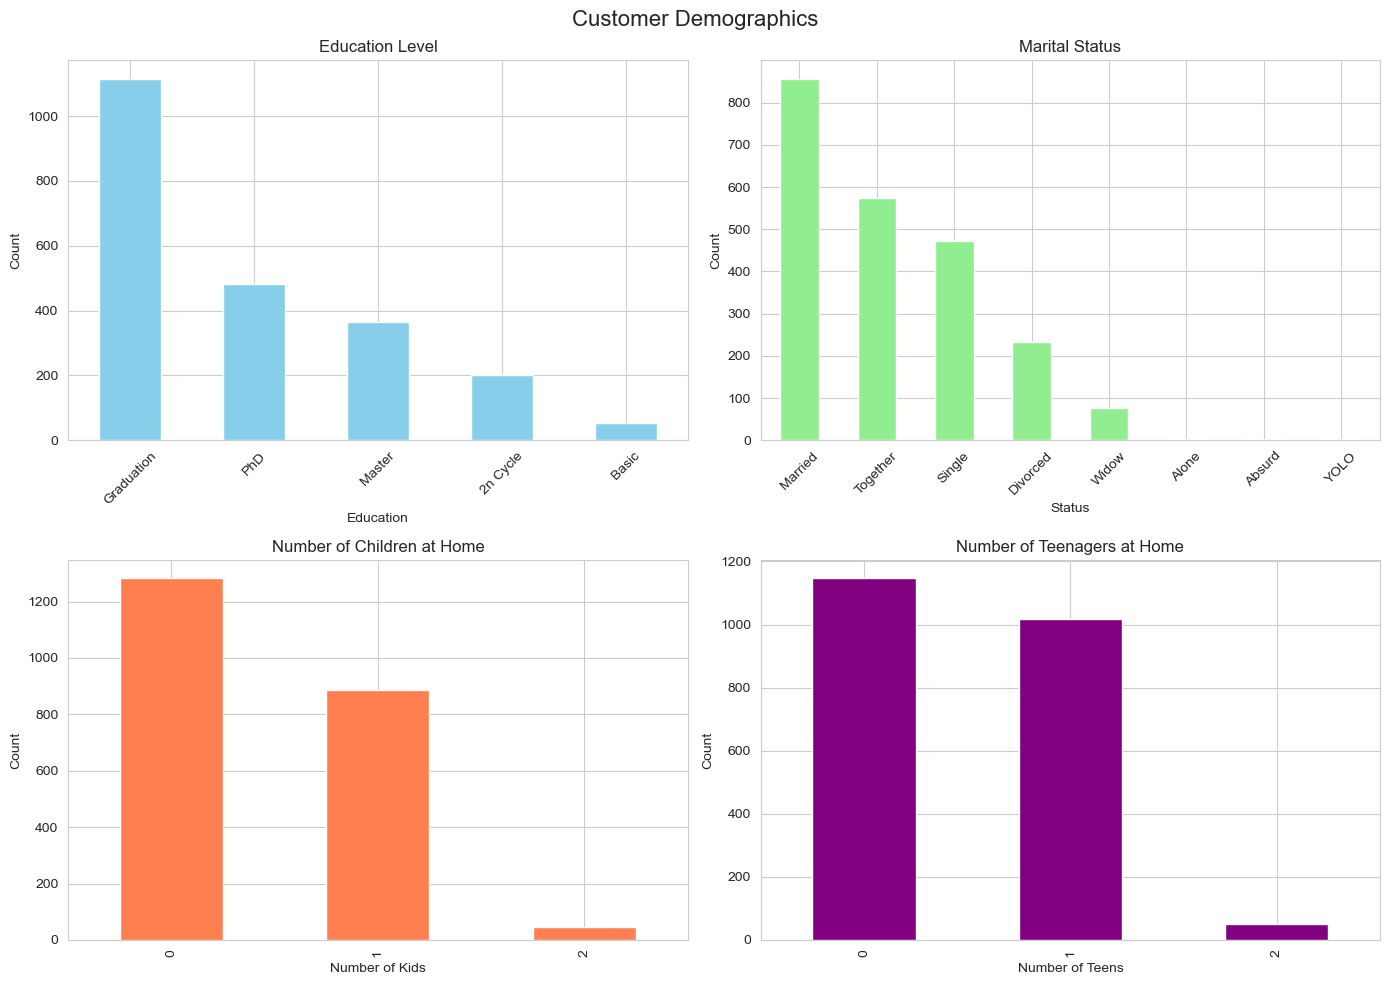

/var/folders/vr/wv5h83lx5zz2jks4yf6w3hsc0000gn/T/ipykernel_1993/4145932680.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Total_Spent_Temp'] = df_clean[spending_cols].sum(axis=1)


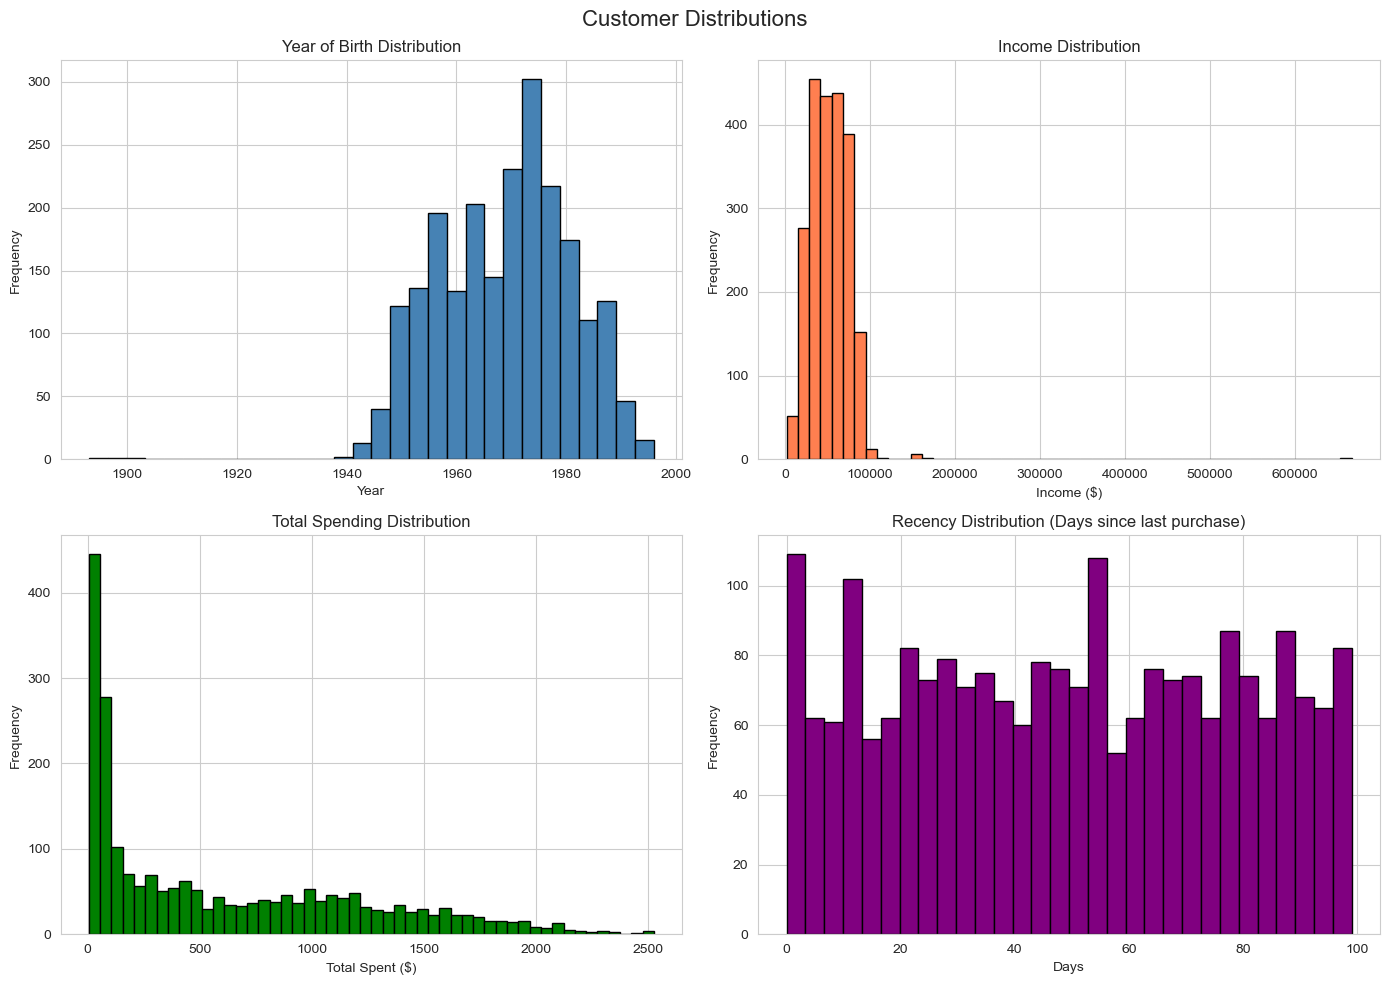

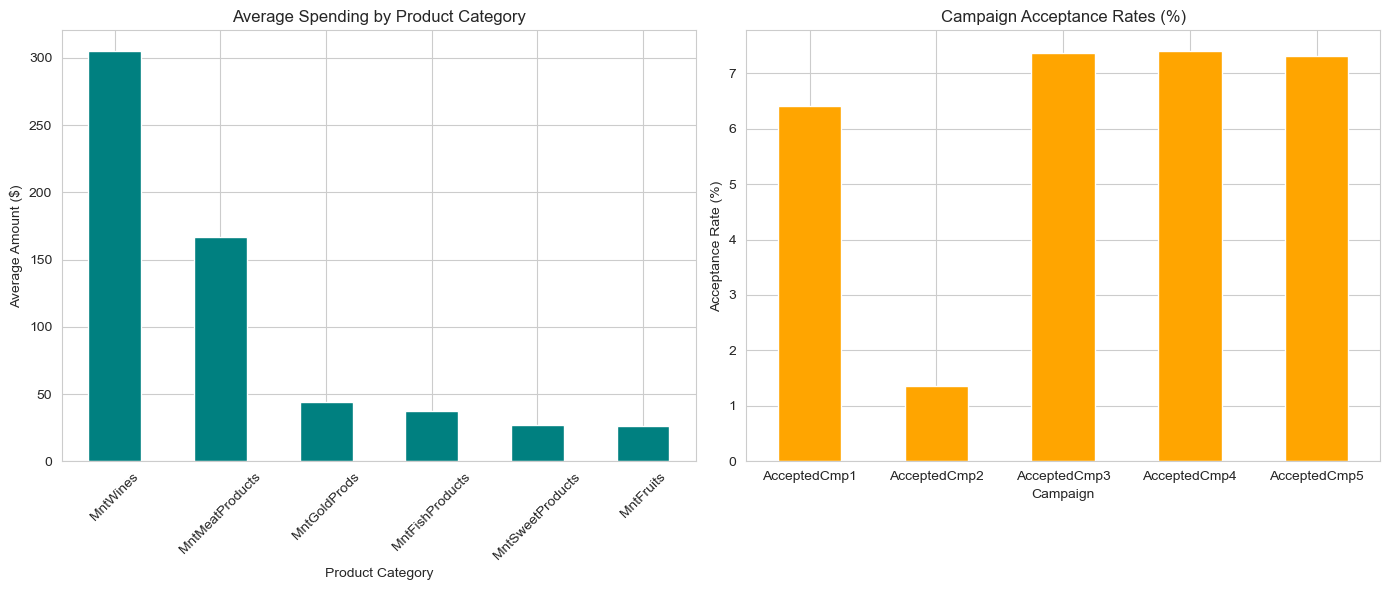

In [4]:
# 2.1 Plot 1: Categorical Variables (Education, Marital Status, Kids, Teens)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Demographics', fontsize=16)

# Education
df_clean['Education'].value_counts().plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Education Level')
axes[0,0].set_xlabel('Education')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)

# Marital Status
df_clean['Marital_Status'].value_counts().plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Marital Status')
axes[0,1].set_xlabel('Status')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)

# Kidhome
df_clean['Kidhome'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='coral')
axes[1,0].set_title('Number of Children at Home')
axes[1,0].set_xlabel('Number of Kids')
axes[1,0].set_ylabel('Count')

# Teenhome
df_clean['Teenhome'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Number of Teenagers at Home')
axes[1,1].set_xlabel('Number of Teens')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# 2.2 Plot 2: Distribution Plots (Year_Birth, Income, Total Spending)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Distributions', fontsize=16)

# Year_Birth distribution
axes[0,0].hist(df_clean['Year_Birth'], bins=30, color='steelblue', edgecolor='black')
axes[0,0].set_title('Year of Birth Distribution')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Frequency')

# Income distribution
axes[0,1].hist(df_clean['Income'], bins=50, color='coral', edgecolor='black')
axes[0,1].set_title('Income Distribution')
axes[0,1].set_xlabel('Income ($)')
axes[0,1].set_ylabel('Frequency')

# Total spending (sum of all product purchases)
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 
                 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_clean['Total_Spent_Temp'] = df_clean[spending_cols].sum(axis=1)

axes[1,0].hist(df_clean['Total_Spent_Temp'], bins=50, color='green', edgecolor='black')
axes[1,0].set_title('Total Spending Distribution')
axes[1,0].set_xlabel('Total Spent ($)')
axes[1,0].set_ylabel('Frequency')

# Average spending per transaction (using Recency as proxy for frequency)
axes[1,1].hist(df_clean['Recency'], bins=30, color='purple', edgecolor='black')
axes[1,1].set_title('Recency Distribution (Days since last purchase)')
axes[1,1].set_xlabel('Days')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 2.3 Plot 3: Spending by Product Category and Campaign Acceptance

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average spending by product category
avg_spending = df_clean[spending_cols].mean().sort_values(ascending=False)
avg_spending.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Average Spending by Product Category')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Average Amount ($)')
axes[0].tick_params(axis='x', rotation=45)

# Campaign acceptance rates
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
acceptance_rates = df_clean[campaign_cols].mean() * 100
acceptance_rates.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Campaign Acceptance Rates (%)')
axes[1].set_xlabel('Campaign')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [5]:
#3: Data Preprocessing & Feature Engineering

In [6]:
# 3.1 Descriptive statistics
print("DESCRIPTIVE STATISTICS:")
print(df_clean.describe().T)

# 3.2 Convert Dt_Customer to datetime
df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'], format='%d-%m-%Y')
print(f"\nEarliest customer date: {df_clean['Dt_Customer'].min()}")
print(f"Latest customer date: {df_clean['Dt_Customer'].max()}")

# 3.3 Create new features (using the original df before removing columns)
df_clean['Age'] = 2021 - df_clean['Year_Birth']
df_clean['Total_Spent'] = df_clean[spending_cols].sum(axis=1)
df_clean['Partner'] = df_clean['Marital_Status'].apply(lambda x: 1 if x in ['Married', 'Together'] else 0)
df_clean['Children'] = df_clean['Kidhome'] + df_clean['Teenhome']
df_clean['Family_Size'] = df_clean['Children'] + df_clean['Partner'] + 1  # +1 for the customer
df_clean['Customer_For'] = (pd.to_datetime('2021-12-31') - df_clean['Dt_Customer']).dt.days

print("\n✅ NEW FEATURES CREATED:")
print(f"  - Age (min: {df_clean['Age'].min()}, max: {df_clean['Age'].max()})")
print(f"  - Total_Spent (min: {df_clean['Total_Spent'].min()}, max: {df_clean['Total_Spent'].max()})")
print(f"  - Partner (0/1): {df_clean['Partner'].value_counts().to_dict()}")
print(f"  - Children (0-4): {df_clean['Children'].value_counts().sort_index().to_dict()}")
print(f"  - Family_Size (1-6): {df_clean['Family_Size'].value_counts().sort_index().to_dict()}")
print(f"  - Customer_For (days): {df_clean['Customer_For'].min()} to {df_clean['Customer_For'].max()} days")

# 3.4 Drop unnecessary columns
columns_to_drop = ['Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'Year_Birth', 'ID']
df_clean = df_clean.drop(columns=columns_to_drop, errors='ignore')

print(f"\n✅ Removed columns: {columns_to_drop}")
print(f"Final dataset shape: {df_clean.shape}")

# 3.5 Verify final structure
print("\n" + "="*60)
print("FINAL DATASET INFO:")
print("="*60)
print(df_clean.info())

DESCRIPTIVE STATISTICS:
                      count          mean           std     min       25%  \
ID                   2216.0   5588.353339   3249.376275     0.0   2814.75   
Year_Birth           2216.0   1968.820397     11.985554  1893.0   1959.00   
Income               2216.0  52247.251354  25173.076661  1730.0  35303.00   
Kidhome              2216.0      0.441787      0.536896     0.0      0.00   
Teenhome             2216.0      0.505415      0.544181     0.0      0.00   
Recency              2216.0     49.012635     28.948352     0.0     24.00   
MntWines             2216.0    305.091606    337.327920     0.0     24.00   
MntFruits            2216.0     26.356047     39.793917     0.0      2.00   
MntMeatProducts      2216.0    166.995939    224.283273     0.0     16.00   
MntFishProducts      2216.0     37.637635     54.752082     0.0      3.00   
MntSweetProducts     2216.0     27.028881     41.072046     0.0      1.00   
MntGoldProds         2216.0     43.965253     51.815

/var/folders/vr/wv5h83lx5zz2jks4yf6w3hsc0000gn/T/ipykernel_1993/2493269826.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'], format='%d-%m-%Y')
/var/folders/vr/wv5h83lx5zz2jks4yf6w3hsc0000gn/T/ipykernel_1993/2493269826.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Age'] = 2021 - df_clean['Year_Birth']
/var/folders/vr/wv5h83lx5zz2jks4yf6w3hsc0000gn/T/ipykernel_1993/2493269826.py:12: SettingWithCopyWarning: 
A value is trying

In [7]:
#4: Exploratory Data Analysis & Encoding

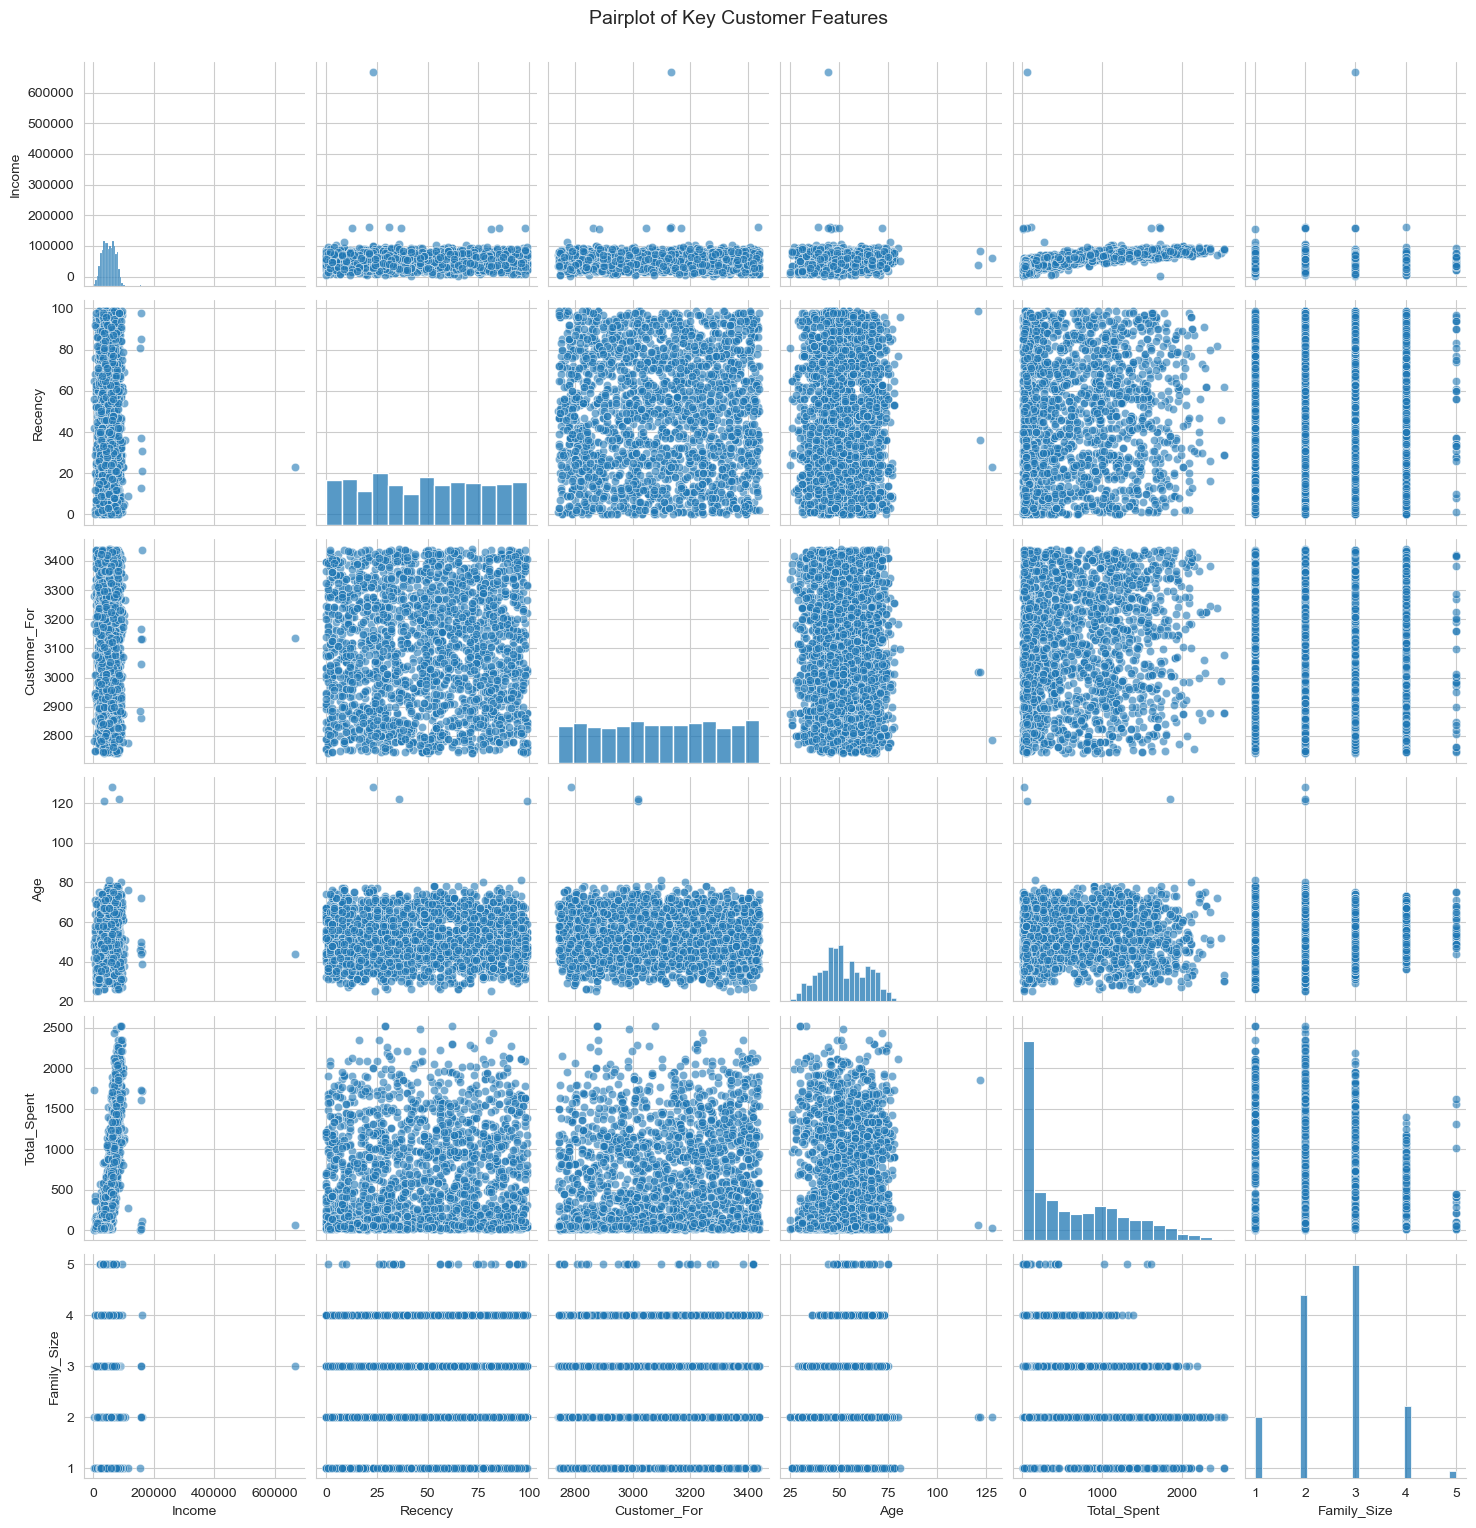

REMOVING OUTLIERS:
  Age: removed 3 outliers (kept 2213)
  Income: removed 8 outliers (kept 2205)

Final rows after outlier removal: 2205
  Education: {'2n Cycle': 0, 'Basic': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
  Marital_Status: {'Absurd': 0, 'Alone': 1, 'Divorced': 2, 'Married': 3, 'Single': 4, 'Together': 5, 'Widow': 6, 'YOLO': 7}

CLEANED DATA STATISTICS:
                         count          mean           std     min      25%  \
Income                  2205.0  51622.094785  20713.063826  1730.0  35196.0   
Kidhome                 2205.0      0.442177      0.537132     0.0      0.0   
Teenhome                2205.0      0.506576      0.544380     0.0      0.0   
Recency                 2205.0     49.009070     28.932111     0.0     24.0   
MntWines                2205.0    306.164626    337.493839     0.0     24.0   
MntFruits               2205.0     26.403175     39.784484     0.0      2.0   
MntMeatProducts         2205.0    165.312018    217.784507     0.0     16.0   

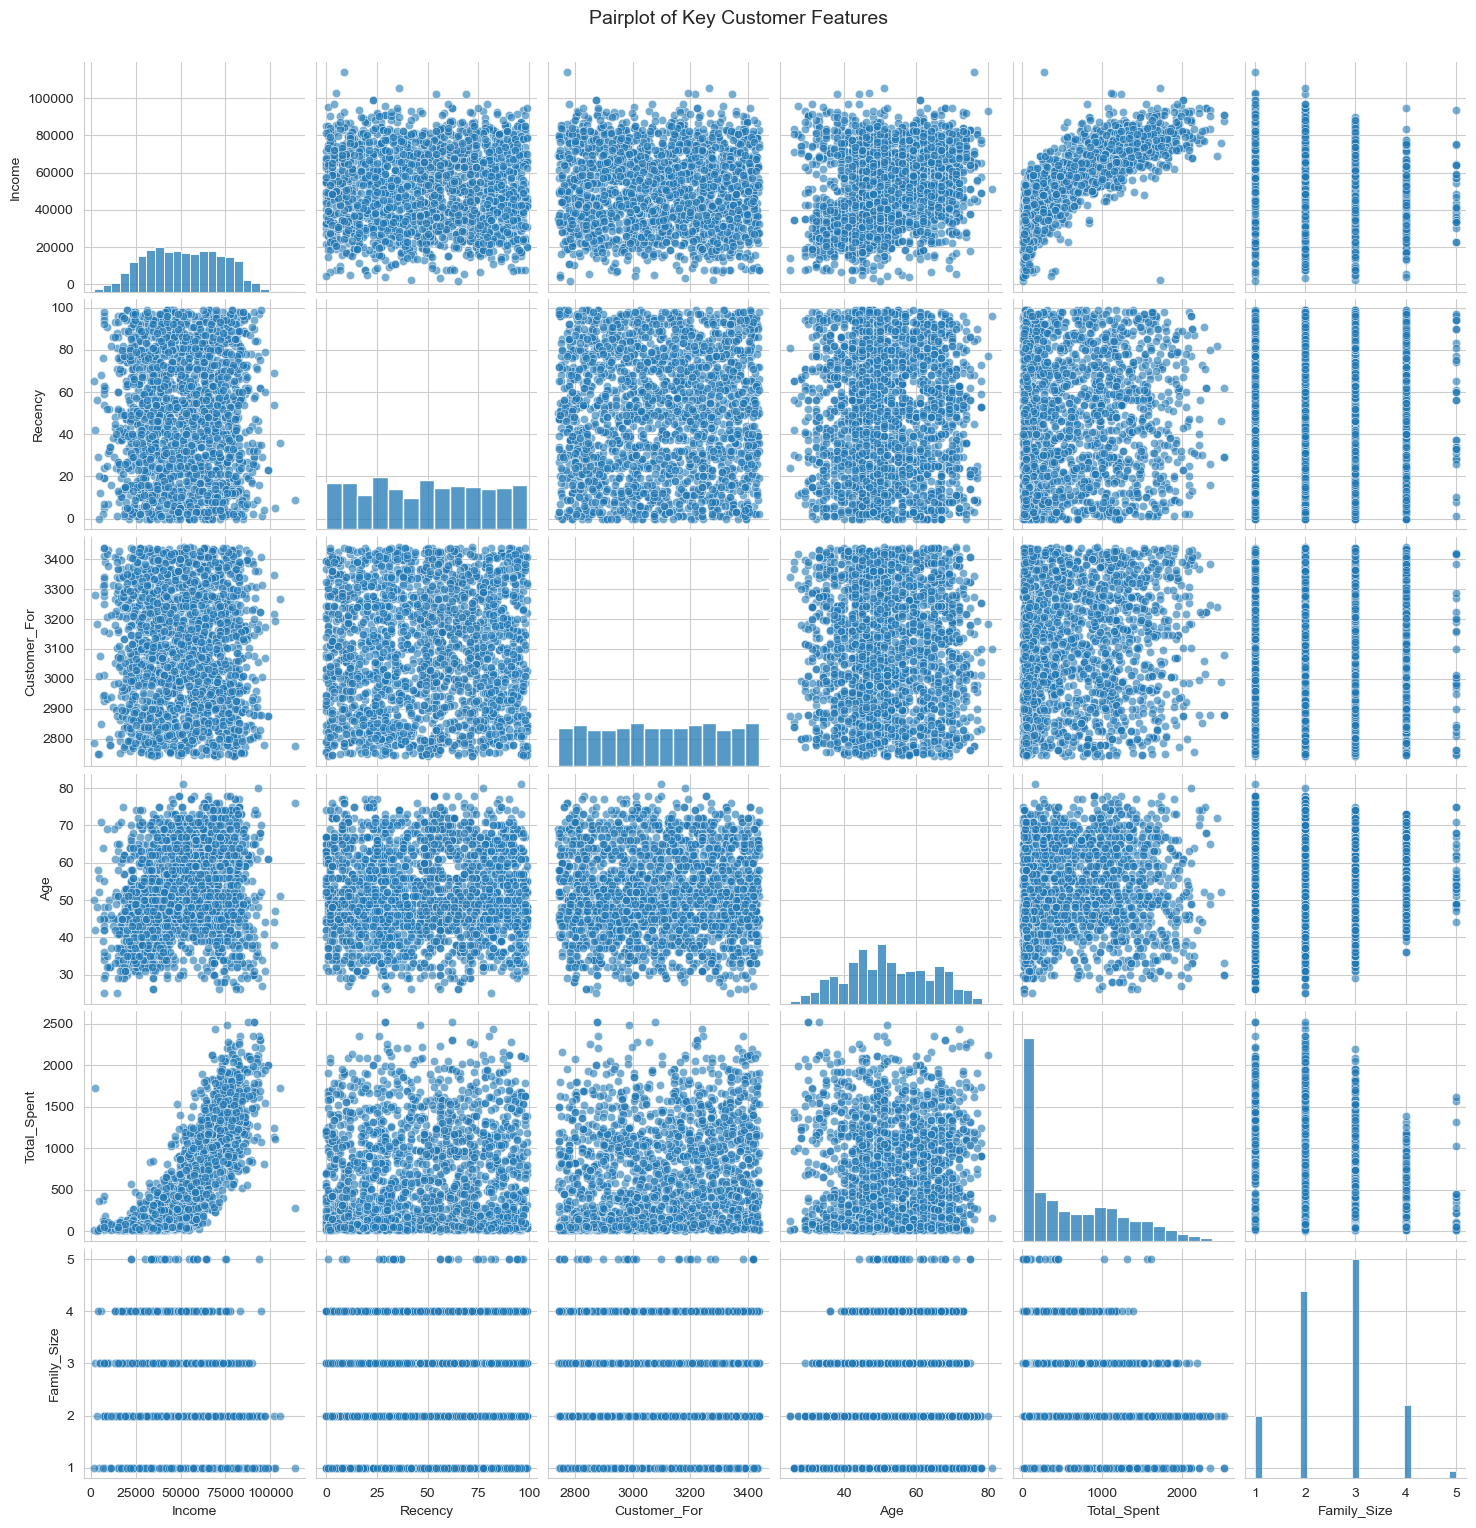

In [8]:
# 4.1 Pairplot for key numerical columns
key_cols = ['Income', 'Recency', 'Customer_For', 'Age', 'Total_Spent', 'Family_Size']
sns.pairplot(df_clean[key_cols], diag_kind='hist', plot_kws={'alpha':0.6})
plt.suptitle('Pairplot of Key Customer Features', y=1.02, fontsize=14)
plt.show()

# 4.2 Remove outliers using IQR method for Age and Income

def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    before = len(df)
    df_clean = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    after = len(df_clean)
    print(f"  {column}: removed {before - after} outliers (kept {after})")
    return df_clean

print("REMOVING OUTLIERS:")
df_clean = remove_outliers_iqr(df_clean, 'Age')
df_clean = remove_outliers_iqr(df_clean, 'Income')

print(f"\nFinal rows after outlier removal: {len(df_clean)}")

# 4.3 Encode categorical variables
label_encoders = {}

categorical_cols = ['Education', 'Marital_Status']
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col + '_Encoded'] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 4.4 Verify the cleaned data
print("\n" + "="*60)
print("CLEANED DATA STATISTICS:")
print("="*60)
print(df_clean.describe().T)

key_cols = ['Income', 'Recency', 'Customer_For', 'Age', 'Total_Spent', 'Family_Size']
sns.pairplot(df_clean[key_cols], diag_kind='hist', plot_kws={'alpha':0.6})
plt.suptitle('Pairplot of Key Customer Features', y=1.02, fontsize=14)
plt.show()

In [9]:
#5: Correlation Analysis & Feature Scaling


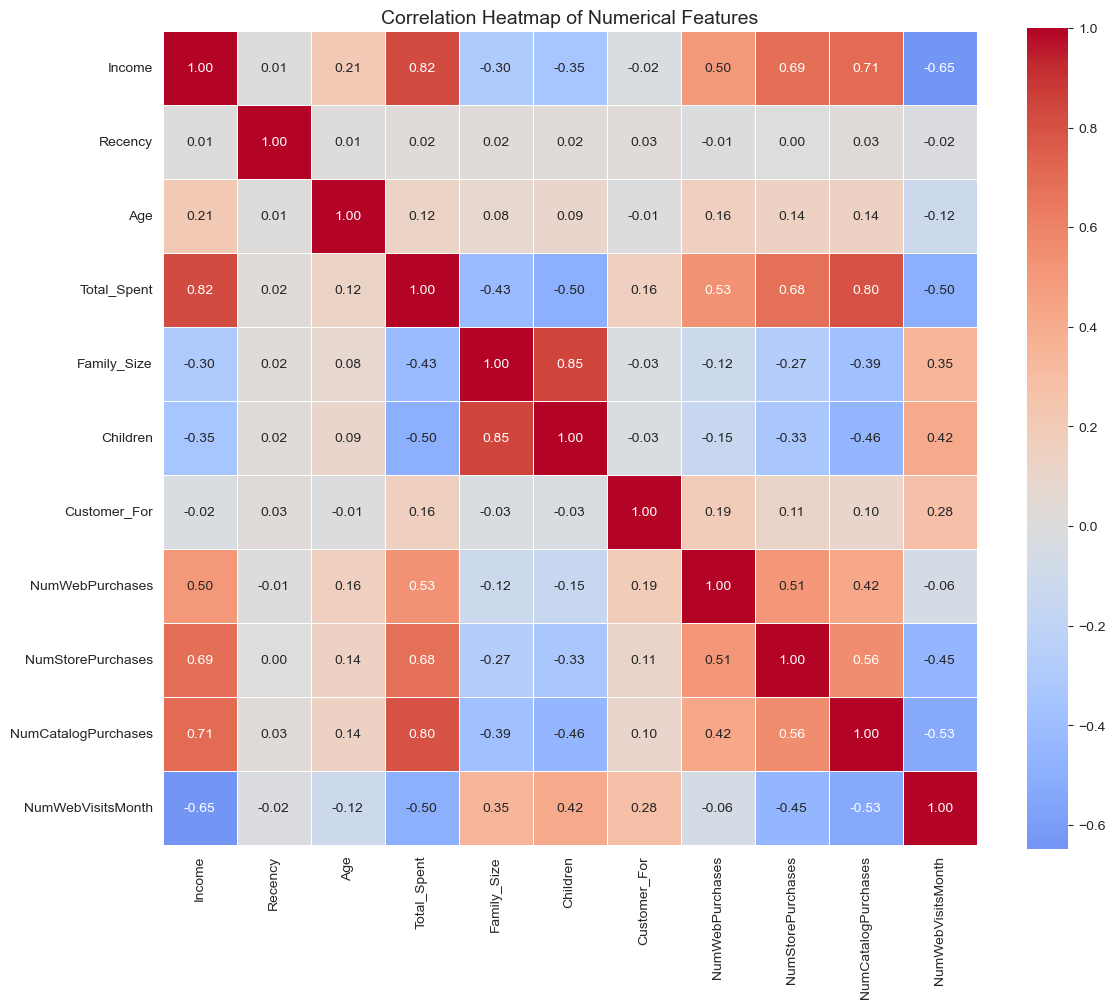


🔍 KEY CORRELATION INSIGHTS:
  - Total_Spent vs Income: 0.82
  - Total_Spent vs NumWebPurchases: 0.53
  - Recency vs Total_Spent: 0.02

Dataset for scaling shape: (2205, 26)

Numerical features (20): ['Income', 'Recency', 'Age', 'Total_Spent', 'Family_Size']...
Categorical features (3): ['Education_Encoded', 'Marital_Status_Encoded', 'Partner']

✅ Scaled dataset shape: (2205, 23)

First 5 rows of scaled dataset:
     Income   Recency       Age  Total_Spent  Family_Size  Children  \
0  0.314651  0.310830  1.017189     1.679323    -1.759012 -1.266589   
1 -0.254877 -0.380600  1.273530    -0.963897     0.448513  1.403420   
2  0.965354 -0.795458  0.333612     0.281242    -0.655250 -1.266589   
3 -1.206087 -0.795458 -1.289883    -0.920675     0.448513  0.068415   
4  0.322136  1.555404 -1.033542    -0.307248     0.448513  0.068415   

   Customer_For   Kidhome  Teenhome  MntWines  ...  MntSweetProducts  \
0      1.527183 -0.823405 -0.930767  0.974566  ...          1.480301   
1     -1.1886

In [10]:
# 5.1 Select numerical columns for correlation
numerical_cols = ['Income', 'Recency', 'Age', 'Total_Spent', 'Family_Size', 
                  'Children', 'Customer_For', 'NumWebPurchases', 'NumStorePurchases',
                  'NumCatalogPurchases', 'NumWebVisitsMonth']

# 5.2 Create correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df_clean[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

print("\n🔍 KEY CORRELATION INSIGHTS:")
print(f"  - Total_Spent vs Income: {correlation_matrix.loc['Total_Spent', 'Income']:.2f}")
print(f"  - Total_Spent vs NumWebPurchases: {correlation_matrix.loc['Total_Spent', 'NumWebPurchases']:.2f}")
print(f"  - Recency vs Total_Spent: {correlation_matrix.loc['Recency', 'Total_Spent']:.2f}")

# 5.3 Prepare dataset for scaling (remove target columns)
target_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 
               'AcceptedCmp5', 'Complain', 'Response']
df_for_scaling = df_clean.drop(columns=target_cols, errors='ignore')

print(f"\nDataset for scaling shape: {df_for_scaling.shape}")

# 5.4 Identify numerical and categorical columns
numerical_features = ['Income', 'Recency', 'Age', 'Total_Spent', 'Family_Size', 
                      'Children', 'Customer_For', 'Kidhome', 'Teenhome',
                      'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
                      'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
                      'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
                      'NumWebVisitsMonth']

categorical_features = ['Education_Encoded', 'Marital_Status_Encoded', 'Partner']

# Make sure all columns exist
numerical_features = [col for col in numerical_features if col in df_for_scaling.columns]
categorical_features = [col for col in categorical_features if col in df_for_scaling.columns]

print(f"\nNumerical features ({len(numerical_features)}): {numerical_features[:5]}...")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# 5.5 Scale numerical features
scaler = StandardScaler()
scaled_numerical = scaler.fit_transform(df_for_scaling[numerical_features])

# 5.6 Combine scaled numerical with categorical
scaled_df = pd.DataFrame(scaled_numerical, columns=numerical_features, index=df_for_scaling.index)

# Add categorical columns
for col in categorical_features:
    scaled_df[col] = df_for_scaling[col].values

print(f"\n✅ Scaled dataset shape: {scaled_df.shape}")
print("\nFirst 5 rows of scaled dataset:")
print(scaled_df.head())

In [11]:
#6: Dimensionality Reduction with PCA

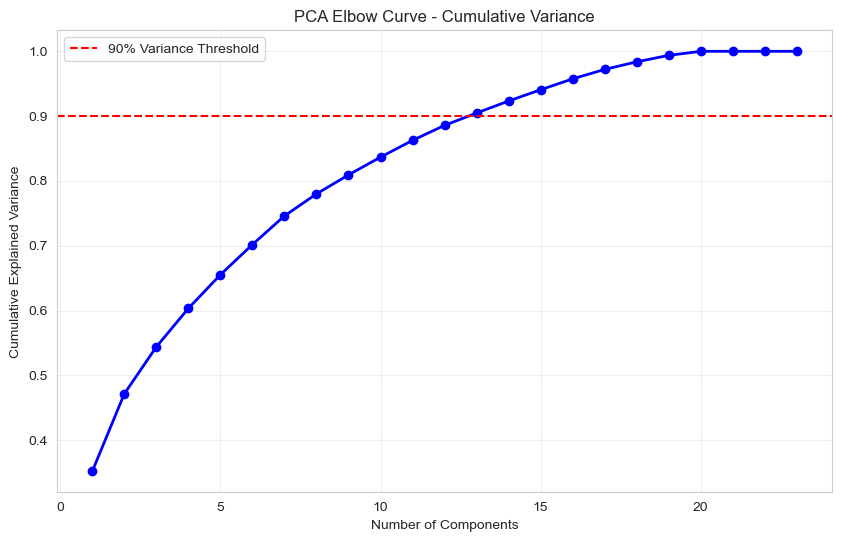


📊 Number of components needed for 90% variance: 13
   Variance explained by 13 components: 90.48%

✅ PCA transformed dataset shape: (2205, 13)

First 5 rows of PCA data:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  4.725825 -0.222592 -1.954434  1.030471  0.817544 -0.097759  0.424576   
1 -2.855387  0.246974  1.326091 -1.501824  0.073189 -0.660060 -0.212042   
2  2.288980 -0.700347  0.189539  0.070080  1.238954 -0.806602 -0.987601   
3 -2.668882 -1.654560 -0.057643 -0.561948  0.912198  0.778063 -1.225123   
4 -0.457861  0.233590  0.292439  0.114180 -1.014174  2.358876  0.955243   

        PC8       PC9      PC10      PC11      PC12      PC13  
0  1.770193  0.776983 -0.120286  1.608675 -0.516667  0.778523  
1  0.462669  0.004488  0.336512  0.866447  0.010105  0.231362  
2 -0.647006 -0.007201 -0.848479 -0.083224 -0.685119 -1.192448  
3 -0.967442  0.032618 -0.168892  0.084778 -0.015603 -0.192022  
4 -0.773693  1.082515 -1.106173  0.560992  0.569774 -0.319

In [12]:
# 6.1 Apply PCA
pca = PCA()
pca_result = pca.fit_transform(scaled_df)

# 6.2 Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 6.3 Plot elbow curve (cumulative variance)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-', linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Elbow Curve - Cumulative Variance')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 6.4 Find number of components for 90% variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"\n📊 Number of components needed for 90% variance: {n_components_90}")
print(f"   Variance explained by {n_components_90} components: {cumulative_variance[n_components_90-1]:.2%}")

# 6.5 Transform data using optimal components
pca_optimal = PCA(n_components=n_components_90)
pca_df = pd.DataFrame(
    pca_optimal.fit_transform(scaled_df),
    columns=[f'PC{i+1}' for i in range(n_components_90)],
    index=scaled_df.index
)

print(f"\n✅ PCA transformed dataset shape: {pca_df.shape}")
print("\nFirst 5 rows of PCA data:")
print(pca_df.head())

In [13]:
#7: K-Means Clustering

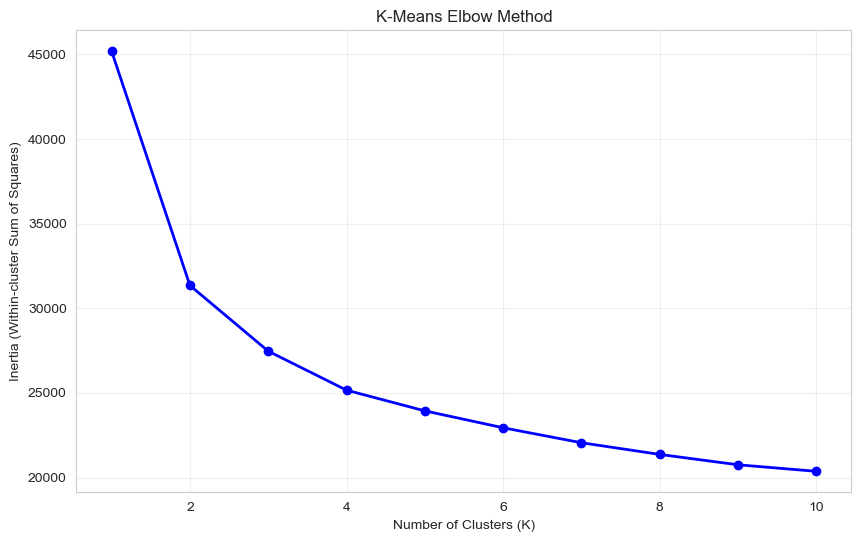


🎯 Optimal number of clusters (from elbow): K = 3

✅ Cluster assignments complete!
Cluster distribution:
Cluster
0     565
1     606
2    1034
Name: count, dtype: int64


In [14]:
# 7.1 Elbow method to find optimal K
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_df)
    inertias.append(kmeans.inertia_)

# 7.2 Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('K-Means Elbow Method')
plt.grid(True, alpha=0.3)
plt.show()

# 7.3 Based on elbow, choose K=3 (the elbow is clearly at 3)
optimal_k = 3
print(f"\n🎯 Optimal number of clusters (from elbow): K = {optimal_k}")

# 7.4 Apply final K-Means model
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['Cluster'] = final_kmeans.fit_predict(pca_df)

print(f"\n✅ Cluster assignments complete!")
print(f"Cluster distribution:")
print(df_clean['Cluster'].value_counts().sort_index())

# Add cluster to PCA dataframe for visualization
pca_df['Cluster'] = df_clean['Cluster'].values

In [15]:
#8: 3D Visualization of Clusters

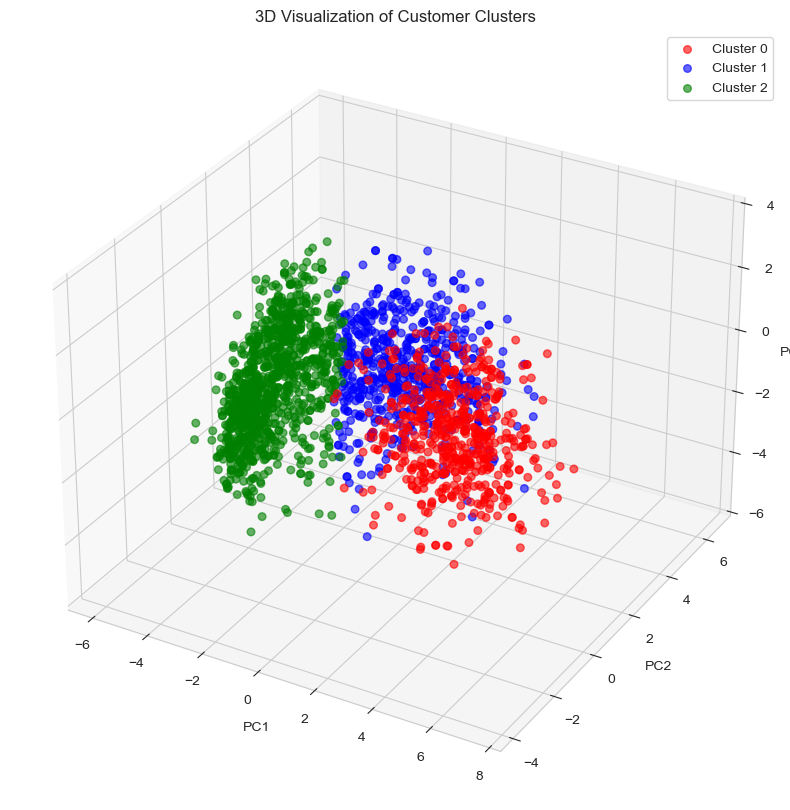

✅ 3D cluster visualization complete!


In [16]:
# 8.1 Check if we have at least 3 PCA components for 3D plot
if n_components_90 >= 3:
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot each cluster with different color
    colors = ['red', 'blue', 'green']
    for cluster in range(optimal_k):
        cluster_data = pca_df[pca_df['Cluster'] == cluster]
        ax.scatter(cluster_data['PC1'], cluster_data['PC2'], cluster_data['PC3'],
                   c=colors[cluster], label=f'Cluster {cluster}', alpha=0.6, s=30)
    
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title('3D Visualization of Customer Clusters')
    ax.legend()
    
    plt.show()
    print("✅ 3D cluster visualization complete!")
else:
    print(f"⚠️ Only {n_components_90} components available. Need at least 3 for 3D plot.")
    print("Creating 2D scatter plot instead:")
    
    plt.figure(figsize=(10, 8))
    for cluster in range(optimal_k):
        cluster_data = pca_df[pca_df['Cluster'] == cluster]
        plt.scatter(cluster_data['PC1'], cluster_data['PC2'], 
                   label=f'Cluster {cluster}', alpha=0.6, s=30)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('2D Visualization of Customer Clusters')
    plt.legend()
    plt.show()

In [17]:
#9: Cluster Profiling & Insights

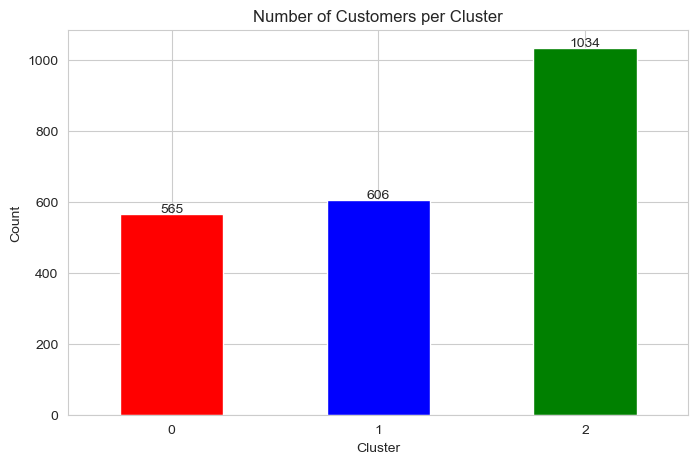


📊 CLUSTER SIZE SUMMARY:
  Cluster 0: 565 customers (25.6%)
  Cluster 1: 606 customers (27.5%)
  Cluster 2: 1034 customers (46.9%)


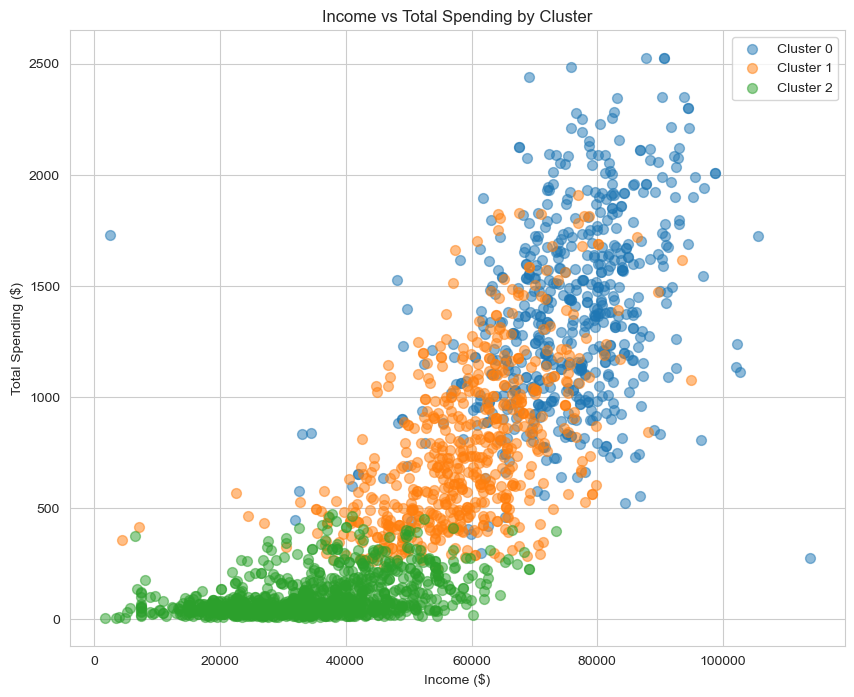

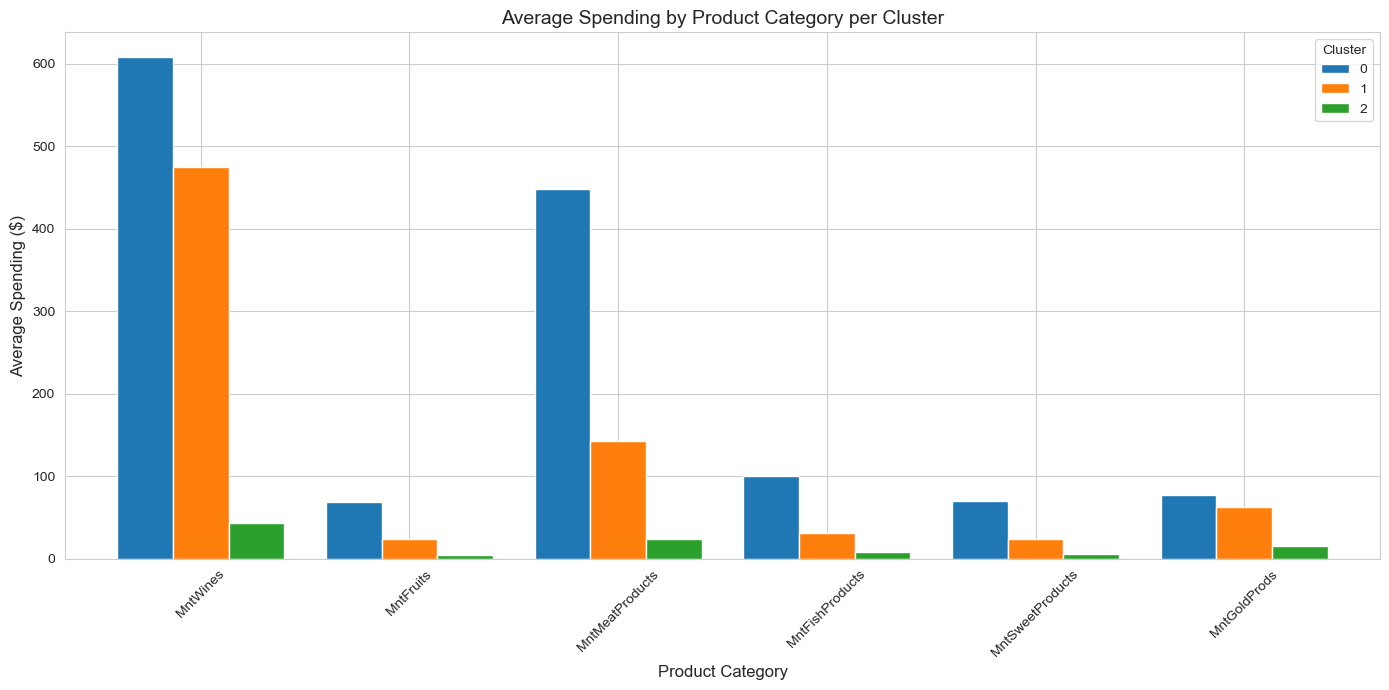

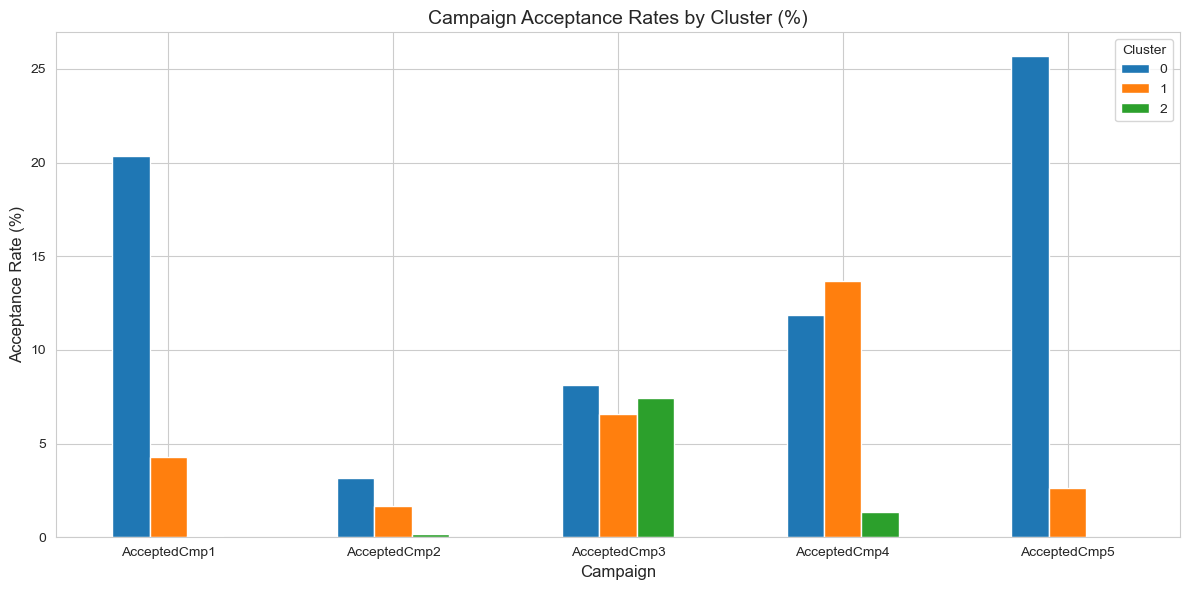

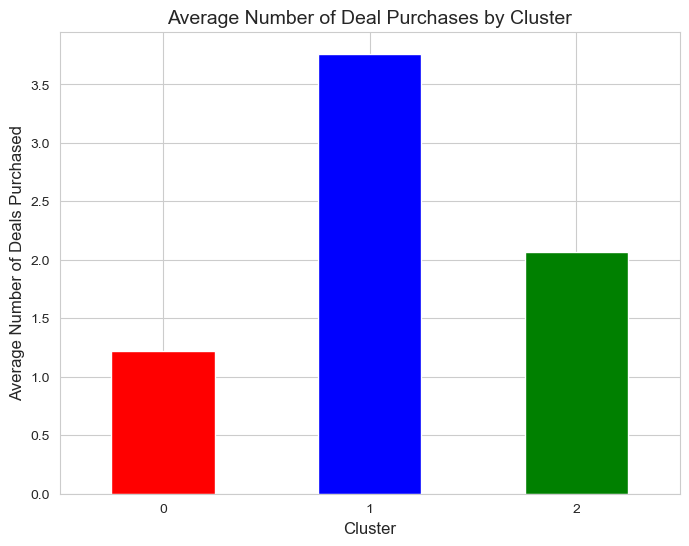

In [18]:
# 9.1 Cluster size distribution
plt.figure(figsize=(8, 5))
cluster_sizes = df_clean['Cluster'].value_counts().sort_index()
cluster_sizes.plot(kind='bar', color=['red', 'blue', 'green'])
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(cluster_sizes.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

print("\n📊 CLUSTER SIZE SUMMARY:")
for cluster in range(optimal_k):
    size = cluster_sizes[cluster]
    percentage = size / len(df_clean) * 100
    print(f"  Cluster {cluster}: {size} customers ({percentage:.1f}%)")

# 9.2 Income vs Total Spending by Cluster
plt.figure(figsize=(10, 8))
for cluster in range(optimal_k):
    cluster_data = df_clean[df_clean['Cluster'] == cluster]
    plt.scatter(cluster_data['Income'], cluster_data['Total_Spent'], 
               label=f'Cluster {cluster}', alpha=0.5, s=50)
plt.xlabel('Income ($)')
plt.ylabel('Total Spending ($)')
plt.title('Income vs Total Spending by Cluster')
plt.legend()
plt.show()

# 9.3 Average spending by product category for each cluster
product_categories = ['MntWines', 'MntFruits', 'MntMeatProducts', 
                      'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

cluster_spending = df_clean.groupby('Cluster')[product_categories].mean()

# Plot grouped bar chart
cluster_spending.T.plot(kind='bar', figsize=(14, 7), width=0.8)
plt.title('Average Spending by Product Category per Cluster', fontsize=14)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Average Spending ($)', fontsize=12)
plt.legend(title='Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 9.4 Campaign performance by cluster
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
campaign_acceptance = df_clean.groupby('Cluster')[campaign_cols].mean() * 100

campaign_acceptance.T.plot(kind='bar', figsize=(12, 6))
plt.title('Campaign Acceptance Rates by Cluster (%)', fontsize=14)
plt.xlabel('Campaign', fontsize=12)
plt.ylabel('Acceptance Rate (%)', fontsize=12)
plt.legend(title='Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 9.5 Deal purchases by cluster
plt.figure(figsize=(8, 6))
df_clean.groupby('Cluster')['NumDealsPurchases'].mean().plot(kind='bar', color=['red', 'blue', 'green'])
plt.title('Average Number of Deal Purchases by Cluster', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Average Number of Deals Purchased', fontsize=12)
plt.xticks(rotation=0)
plt.show()

In [19]:
#10: Cluster Descriptions

In [20]:
# Calculate key metrics for each cluster
cluster_summary = df_clean.groupby('Cluster').agg({
    'Age': 'mean',
    'Income': 'mean',
    'Total_Spent': 'mean',
    'Children': 'mean',
    'Family_Size': 'mean',
    'Recency': 'mean',
    'NumWebPurchases': 'mean',
    'NumStorePurchases': 'mean',
    'NumCatalogPurchases': 'mean',
    'NumDealsPurchases': 'mean',
    'Partner': 'mean',
    'Response': 'mean'
}).round(2)

print("="*70)
print("CLUSTER PROFILES - KEY METRICS")
print("="*70)
print(cluster_summary)

print("\n" + "="*70)
print("CLUSTER DESCRIPTIONS")
print("="*70)

for cluster in range(optimal_k):
    cluster_data = df_clean[df_clean['Cluster'] == cluster]
    print(f"\n📍 CLUSTER {cluster}:")
    print(f"   Size: {len(cluster_data)} customers")
    print(f"   Average Age: {cluster_data['Age'].mean():.0f} years")
    print(f"   Average Income: ${cluster_data['Income'].mean():,.0f}")
    print(f"   Average Total Spent: ${cluster_data['Total_Spent'].mean():,.0f}")
    print(f"   Average Family Size: {cluster_data['Family_Size'].mean():.1f}")
    print(f"   Average Children: {cluster_data['Children'].mean():.1f}")
    print(f"   Partner Rate: {cluster_data['Partner'].mean()*100:.0f}%")
    print(f"   Avg Recency (days since purchase): {cluster_data['Recency'].mean():.0f}")
    print(f"   Campaign Response Rate: {cluster_data['Response'].mean()*100:.1f}%")
    
    # Determine cluster type based on key metrics
    if cluster_data['Income'].mean() > df_clean['Income'].mean():
        income_level = "High Income"
    else:
        income_level = "Low/Medium Income"
    
    if cluster_data['Total_Spent'].mean() > df_clean['Total_Spent'].mean():
        spending_level = "High Spenders"
    else:
        spending_level = "Low Spenders"
    
    print(f"   👉 Profile: {income_level} | {spending_level}")

CLUSTER PROFILES - KEY METRICS
           Age    Income  Total_Spent  Children  Family_Size  Recency  \
Cluster                                                                 
0        52.71  75311.08      1371.70      0.16         1.76    49.49   
1        56.18  58682.18       758.29      1.19         2.87    48.36   
2        49.37  34540.19       100.11      1.24         2.88    49.13   

         NumWebPurchases  NumStorePurchases  NumCatalogPurchases  \
Cluster                                                            
0                   5.18               8.45                 5.88   
1                   6.44               7.76                 3.18   
2                   2.14               3.25                 0.56   

         NumDealsPurchases  Partner  Response  
Cluster                                        
0                     1.22     0.60      0.28  
1                     3.76     0.68      0.13  
2                     2.07     0.65      0.09  

CLUSTER DESCRIPTIONS


In [21]:
#11: Comparative Analysis

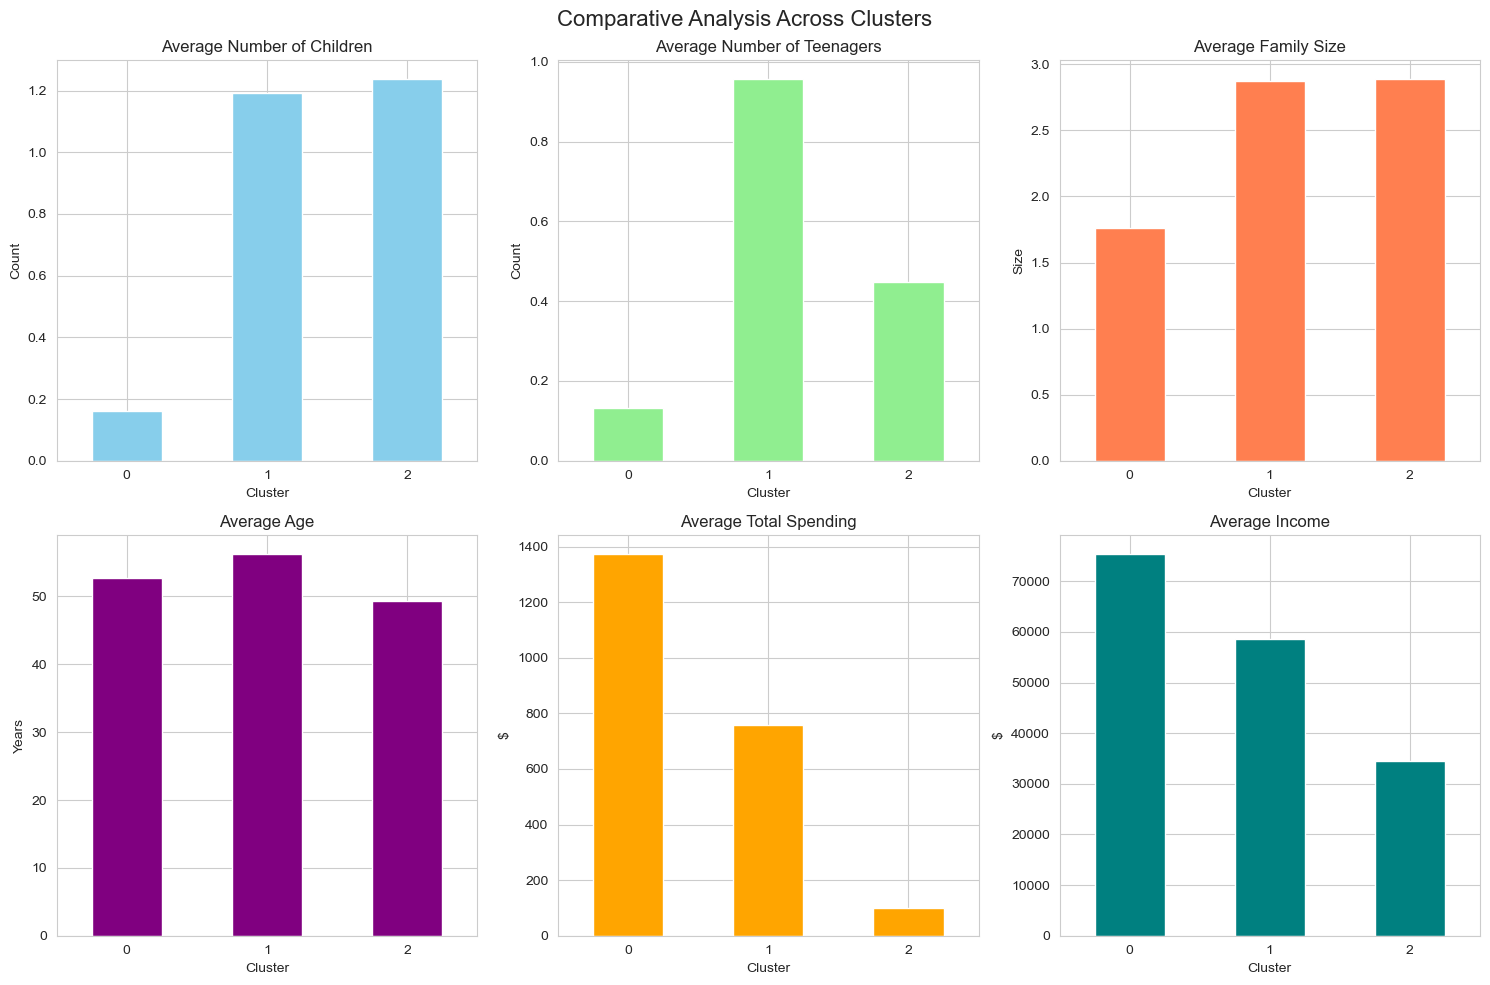


COMPARATIVE ANALYSIS ACROSS CLUSTERS
             Metric Cluster 0 Cluster 1 Cluster 2
   No. of Customers       565       606      1034
            Avg Age        53        56        49
     Avg Income ($)   $75,311   $58,682   $34,540
Avg Total Spent ($)    $1,372      $758      $100
       Avg Children       0.2       1.2       1.2
      Avg Teenagers       0.1       1.0       0.4
    Avg Family Size       1.8       2.9       2.9
        Partner (%)       60%       68%       65%
 Avg Recency (days)        49        48        49
  Response Rate (%)     28.5%     12.5%      9.3%


In [22]:
# 11.1 Create comparative visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Comparative Analysis Across Clusters', fontsize=16)

# Children
df_clean.groupby('Cluster')['Children'].mean().plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Average Number of Children')
axes[0,0].set_ylabel('Count')

# Teenhome
df_clean.groupby('Cluster')['Teenhome'].mean().plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Average Number of Teenagers')
axes[0,1].set_ylabel('Count')

# Family Size
df_clean.groupby('Cluster')['Family_Size'].mean().plot(kind='bar', ax=axes[0,2], color='coral')
axes[0,2].set_title('Average Family Size')
axes[0,2].set_ylabel('Size')

# Age
df_clean.groupby('Cluster')['Age'].mean().plot(kind='bar', ax=axes[1,0], color='purple')
axes[1,0].set_title('Average Age')
axes[1,0].set_ylabel('Years')

# Total Spent
df_clean.groupby('Cluster')['Total_Spent'].mean().plot(kind='bar', ax=axes[1,1], color='orange')
axes[1,1].set_title('Average Total Spending')
axes[1,1].set_ylabel('$')

# Income
df_clean.groupby('Cluster')['Income'].mean().plot(kind='bar', ax=axes[1,2], color='teal')
axes[1,2].set_title('Average Income')
axes[1,2].set_ylabel('$')

for ax in axes.flat:
    ax.set_xlabel('Cluster')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 11.2 Create a summary table
summary_comparison = pd.DataFrame({
    'Metric': ['No. of Customers', 'Avg Age', 'Avg Income ($)', 'Avg Total Spent ($)', 
               'Avg Children', 'Avg Teenagers', 'Avg Family Size', 'Partner (%)', 
               'Avg Recency (days)', 'Response Rate (%)'],
    'Cluster 0': [
        len(df_clean[df_clean['Cluster']==0]),
        f"{df_clean[df_clean['Cluster']==0]['Age'].mean():.0f}",
        f"${df_clean[df_clean['Cluster']==0]['Income'].mean():,.0f}",
        f"${df_clean[df_clean['Cluster']==0]['Total_Spent'].mean():,.0f}",
        f"{df_clean[df_clean['Cluster']==0]['Children'].mean():.1f}",
        f"{df_clean[df_clean['Cluster']==0]['Teenhome'].mean():.1f}",
        f"{df_clean[df_clean['Cluster']==0]['Family_Size'].mean():.1f}",
        f"{df_clean[df_clean['Cluster']==0]['Partner'].mean()*100:.0f}%",
        f"{df_clean[df_clean['Cluster']==0]['Recency'].mean():.0f}",
        f"{df_clean[df_clean['Cluster']==0]['Response'].mean()*100:.1f}%"
    ],
    'Cluster 1': [
        len(df_clean[df_clean['Cluster']==1]),
        f"{df_clean[df_clean['Cluster']==1]['Age'].mean():.0f}",
        f"${df_clean[df_clean['Cluster']==1]['Income'].mean():,.0f}",
        f"${df_clean[df_clean['Cluster']==1]['Total_Spent'].mean():,.0f}",
        f"{df_clean[df_clean['Cluster']==1]['Children'].mean():.1f}",
        f"{df_clean[df_clean['Cluster']==1]['Teenhome'].mean():.1f}",
        f"{df_clean[df_clean['Cluster']==1]['Family_Size'].mean():.1f}",
        f"{df_clean[df_clean['Cluster']==1]['Partner'].mean()*100:.0f}%",
        f"{df_clean[df_clean['Cluster']==1]['Recency'].mean():.0f}",
        f"{df_clean[df_clean['Cluster']==1]['Response'].mean()*100:.1f}%"
    ],
    'Cluster 2': [
        len(df_clean[df_clean['Cluster']==2]),
        f"{df_clean[df_clean['Cluster']==2]['Age'].mean():.0f}",
        f"${df_clean[df_clean['Cluster']==2]['Income'].mean():,.0f}",
        f"${df_clean[df_clean['Cluster']==2]['Total_Spent'].mean():,.0f}",
        f"{df_clean[df_clean['Cluster']==2]['Children'].mean():.1f}",
        f"{df_clean[df_clean['Cluster']==2]['Teenhome'].mean():.1f}",
        f"{df_clean[df_clean['Cluster']==2]['Family_Size'].mean():.1f}",
        f"{df_clean[df_clean['Cluster']==2]['Partner'].mean()*100:.0f}%",
        f"{df_clean[df_clean['Cluster']==2]['Recency'].mean():.0f}",
        f"{df_clean[df_clean['Cluster']==2]['Response'].mean()*100:.1f}%"
    ]
})

print("\n" + "="*100)
print("COMPARATIVE ANALYSIS ACROSS CLUSTERS")
print("="*100)
print(summary_comparison.to_string(index=False))

In [23]:
#12: Marketing Recommendations

In [24]:
print("\n" + "="*70)
print("📈 MARKETING RECOMMENDATIONS BY CLUSTER")
print("="*70)

for cluster in range(optimal_k):
    cluster_data = df_clean[df_clean['Cluster'] == cluster]
    
    print(f"\n🔴 CLUSTER {cluster}:")
    
    # Identify cluster characteristics
    if cluster_data['Income'].mean() > df_clean['Income'].mean():
        income_status = "HIGH INCOME"
    else:
        income_status = "MODERATE/LOW INCOME"
    
    if cluster_data['Total_Spent'].mean() > df_clean['Total_Spent'].mean():
        spending_status = "HIGH SPENDERS"
    else:
        spending_status = "MODERATE/LOW SPENDERS"
    
    # Top product categories for this cluster
    top_products = cluster_data[product_categories].mean().sort_values(ascending=False).head(3)
    
    print(f"   👤 Profile: {income_status} | {spending_status}")
    print(f"   📊 Key Stats:")
    print(f"      - Age: {cluster_data['Age'].mean():.0f} years")
    print(f"      - Income: ${cluster_data['Income'].mean():,.0f}")
    print(f"      - Family Size: {cluster_data['Family_Size'].mean():.1f}")
    print(f"   🛒 Top 3 Product Categories:")
    for cat, val in top_products.items():
        print(f"      - {cat.replace('Mnt', '')}: ${val:.0f}")
    print(f"   💡 Recommendation:")
    
    if income_status == "HIGH INCOME" and spending_status == "HIGH SPENDERS":
        print(f"      → Premium customer segment. Offer loyalty programs, exclusive products,")
        print(f"        and VIP experiences. Focus on wine and meat products (their top categories).")
    elif income_status == "HIGH INCOME" and spending_status == "MODERATE/LOW SPENDERS":
        print(f"      → High income but low spending. Target with personalized offers and")
        print(f"        highlight premium products. They have potential to spend more.")
    elif income_status == "MODERATE/LOW INCOME" and spending_status == "HIGH SPENDERS":
        print(f"      → Value-conscious but loyal customers. Offer bundle deals, discounts,")
        print(f"        and rewards programs. Focus on maintaining their loyalty.")
    else:  # MODERATE/LOW INCOME and MODERATE/LOW SPENDERS
        print(f"      → Budget-conscious customers. Offer basic products at competitive prices,")
        print(f"        and consider email marketing with special discounts to increase engagement.")


📈 MARKETING RECOMMENDATIONS BY CLUSTER

🔴 CLUSTER 0:
   👤 Profile: HIGH INCOME | HIGH SPENDERS
   📊 Key Stats:
      - Age: 53 years
      - Income: $75,311
      - Family Size: 1.8
   🛒 Top 3 Product Categories:
      - Wines: $607
      - MeatProducts: $448
      - FishProducts: $100
   💡 Recommendation:
      → Premium customer segment. Offer loyalty programs, exclusive products,
        and VIP experiences. Focus on wine and meat products (their top categories).

🔴 CLUSTER 1:
   👤 Profile: HIGH INCOME | HIGH SPENDERS
   📊 Key Stats:
      - Age: 56 years
      - Income: $58,682
      - Family Size: 2.9
   🛒 Top 3 Product Categories:
      - Wines: $474
      - MeatProducts: $143
      - GoldProds: $62
   💡 Recommendation:
      → Premium customer segment. Offer loyalty programs, exclusive products,
        and VIP experiences. Focus on wine and meat products (their top categories).

🔴 CLUSTER 2:
   👤 Profile: MODERATE/LOW INCOME | MODERATE/LOW SPENDERS
   📊 Key Stats:
      - Age: